In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print(f"Pandas version: {pd.__version__}") # Print pandas version to confirm installation

Pandas version: 2.2.3


In [2]:
# Read the CSV file
# and store into a DataFrame

file = "EPC_SouthYorkshire_Clean_202604.csv"
dfimport = pd.read_csv(file)

In [3]:
dfimport.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528925 entries, 0 to 528924
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Unnamed: 0                 528925 non-null  int64  
 1   certificate_number         528925 non-null  object 
 2   current_energy_efficiency  528925 non-null  int64  
 3   current_energy_rating      528925 non-null  object 
 4   tenure                     508990 non-null  object 
 5   property_type              528920 non-null  object 
 6   transaction_type           528317 non-null  object 
 7   construction_age_band      469907 non-null  object 
 8   built_form                 525543 non-null  object 
 9   floor_height               525647 non-null  float64
 10  flat_storey_count          520012 non-null  float64
 11  total_floor_area           528924 non-null  float64
 12  postcode                   528925 non-null  object 
 13  constituency_label         52

In [4]:
dfALL = dfimport[["certificate_number",
                  "property_type",
               "built_form",
               "construction_age_band",
               "floor_height",
               "flat_storey_count",
               "total_floor_area"
              ]]

In [5]:
dfALL.head(2)

,certificate_number,property_type,built_form,construction_age_band,floor_height,flat_storey_count,total_floor_area
0,5000-0453-0822-8625-3763,House,Mid-Terrace,1900-1929,3.01,2.0,79.0
1,5000-0608-0522-2677-3763,House,Semi-Detached,1930-1949,2.44,2.0,76.0


In [6]:
# Get to know data
property_type_list = dfALL['property_type'].unique()
print("\nproperty_type with index numbers:")
for i, N_property_type in enumerate(property_type_list):
    count_PT = len(dfALL[dfALL['property_type'] == N_property_type ])
    print(f"{i}: {N_property_type} ({count_PT} records)")


property_type with index numbers:
0: House (374674 records)
1: Flat (96209 records)
2: Bungalow (50159 records)
3: Maisonette (7756 records)
4: nan (0 records)
5: Park home (122 records)


In [7]:
# Get to know data
built_form_list = dfALL['built_form'].unique()
print("\nbuilt_form with index numbers:")
for i, N_built_form in enumerate(built_form_list):
    count_BF = len(dfALL[dfALL['built_form'] == N_built_form ])
    print(f"{i}: {N_built_form} ({count_BF} records)")


built_form with index numbers:
0: Mid-Terrace (139379 records)
1: Semi-Detached (216126 records)
2: Detached (89869 records)
3: Unknown (5656 records)
4: End-Terrace (74513 records)
5: nan (0 records)


# Bungalow: B-DT and B-SD

In [8]:
# Dataframe for Bungalow Only
dfb = dfALL[(dfALL.property_type == "Bungalow")]

In [9]:
total_bungalow = dfb['property_type'].value_counts()
print(total_bungalow)

property_type
Bungalow    50159
Name: count, dtype: int64


In [10]:
dfb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50159 entries, 12 to 528920
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   certificate_number     50159 non-null  object 
 1   property_type          50159 non-null  object 
 2   built_form             50126 non-null  object 
 3   construction_age_band  48146 non-null  object 
 4   floor_height           50159 non-null  float64
 5   flat_storey_count      49480 non-null  float64
 6   total_floor_area       50159 non-null  float64
dtypes: float64(3), object(4)
memory usage: 3.1+ MB


In [11]:
dfb['Archetype'] = np.where(dfb['built_form'] == 'Detached', 'B-DT', 'B-SD')

C:\Users\May Zune\AppData\Local\Temp\ipykernel_27828\735402147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfb['Archetype'] = np.where(dfb['built_form'] == 'Detached', 'B-DT', 'B-SD')


In [12]:
dfb.head(2)

,certificate_number,property_type,built_form,construction_age_band,floor_height,flat_storey_count,total_floor_area,Archetype
12,0370-2699-6650-2125-1071,Bungalow,End-Terrace,1976-1982,2.38,1.0,40.0,B-SD
68,0536-1929-9500-0326-7206,Bungalow,Mid-Terrace,1967-1975,2.28,1.0,57.0,B-SD


In [13]:
# get count per type
bungalow = dfb['built_form'].value_counts()
print(bungalow)

built_form
Detached         21349
Semi-Detached    19837
End-Terrace       4522
Mid-Terrace       4418
Name: count, dtype: int64


In [14]:
# get count per type
bungalow_archetype = dfb['Archetype'].value_counts()
print(bungalow_archetype)

Archetype
B-SD    28810
B-DT    21349
Name: count, dtype: int64


# Dataframe for House Only

In [15]:
# Dataframe for House Only
df = dfALL[(dfALL.property_type == "House")]

In [16]:
total_house = df['property_type'].value_counts()
print(total_house)

property_type
House    374674
Name: count, dtype: int64


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 374674 entries, 0 to 528924
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   certificate_number     374674 non-null  object 
 1   property_type          374674 non-null  object 
 2   built_form             373192 non-null  object 
 3   construction_age_band  333779 non-null  object 
 4   floor_height           374674 non-null  float64
 5   flat_storey_count      369735 non-null  float64
 6   total_floor_area       374674 non-null  float64
dtypes: float64(3), object(4)
memory usage: 22.9+ MB


# Detached Houses: DT-R, DT-L and DT-V

In [18]:
# Select "Detached" under Houses
dfd = df[(df.built_form == "Detached")]

In [19]:
cond_DT = [
    dfd['total_floor_area'] <= 150, dfd['total_floor_area'] > 150
]

In [20]:
choice_DT = ['DT-R', 'DT-L or DT-V']

In [21]:
dfd['Archetype'] = np.select(cond_DT, choice_DT, default='Unknown')

C:\Users\May Zune\AppData\Local\Temp\ipykernel_27828\2773433288.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfd['Archetype'] = np.select(cond_DT, choice_DT, default='Unknown')


In [22]:
dfd.head(2)

,certificate_number,property_type,built_form,construction_age_band,floor_height,flat_storey_count,total_floor_area,Archetype
2,2319-6541-1664-1141-2651,House,Detached,1930-1949,2.51,2.0,145.0,DT-R
28,0428-3057-7295-2424-8974,House,Detached,1967-1975,2.37,2.0,135.0,DT-R


In [23]:
dfd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56388 entries, 2 to 528913
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   certificate_number     56388 non-null  object 
 1   property_type          56388 non-null  object 
 2   built_form             56388 non-null  object 
 3   construction_age_band  42479 non-null  object 
 4   floor_height           56388 non-null  float64
 5   flat_storey_count      54778 non-null  float64
 6   total_floor_area       56388 non-null  float64
 7   Archetype              56388 non-null  object 
dtypes: float64(3), object(5)
memory usage: 3.9+ MB


In [24]:
# get count per type
detached_archetype = dfd['Archetype'].value_counts()
print(detached_archetype)

Archetype
DT-R            42502
DT-L or DT-V    13886
Name: count, dtype: int64


# Semi-Detached Houses: SD-R, SD-S and SD-V

In [25]:
# Select "Semi-Detached" under Houses
dfs = df[(df.built_form == "Semi-Detached")]

In [26]:
cond_SD = [
    dfs['total_floor_area'] <= 100,
    (dfs['total_floor_area'] > 100) & (dfs['total_floor_area'] < 150),
    dfs['total_floor_area'] >= 150
]

In [27]:
choice_SD = ['SD-R', 'SD-S', 'SD-V']

In [28]:
dfs['Archetype'] = np.select(cond_SD, choice_SD, default='Unknown')

C:\Users\May Zune\AppData\Local\Temp\ipykernel_27828\189937462.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Archetype'] = np.select(cond_SD, choice_SD, default='Unknown')


In [29]:
dfs.tail(2)

,certificate_number,property_type,built_form,construction_age_band,floor_height,flat_storey_count,total_floor_area,Archetype
528921,0340-2827-9670-2626-0001,House,Semi-Detached,1950-1966,2.40,2.0,83.0,SD-R
528922,5036-1627-1600-0525-0202,House,Semi-Detached,1900-1929,2.45,2.0,76.0,SD-R


In [30]:
# get count per type
semi_archetype = dfs['Archetype'].value_counts()
print(semi_archetype)

Archetype
SD-R    143479
SD-S     23119
SD-V      4926
Name: count, dtype: int64


# End-Terrace Houses: TR-E, TV-E and TG-E

In [31]:
# Select "End-Terrace" under Houses
dfe = df[(df.built_form == "End-Terrace")]

In [32]:
cond_TE = [
    dfe['total_floor_area'] <= 110,
    (dfe['total_floor_area'] > 110) & (dfe['total_floor_area'] < 200),
    dfe['total_floor_area'] >= 200
]

In [33]:
choice_TE = ['TR-E', 'TV-E', 'TG-E']

In [34]:
dfe['Archetype'] = np.select(cond_TE, choice_TE, default='Unknown')

C:\Users\May Zune\AppData\Local\Temp\ipykernel_27828\759632165.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfe['Archetype'] = np.select(cond_TE, choice_TE, default='Unknown')


In [35]:
dfe.head(2)

,certificate_number,property_type,built_form,construction_age_band,floor_height,flat_storey_count,total_floor_area,Archetype
4,9014-3060-5207-0456-6204,House,End-Terrace,1950-1966,2.45,2.0,92.0,TR-E
5,9305-3060-7202-0026-6204,House,End-Terrace,1967-1975,2.28,2.0,89.0,TR-E


In [36]:
# get count per type
endterrace_archetype = dfe['Archetype'].value_counts()
print(endterrace_archetype)

Archetype
TR-E    42253
TV-E     4819
TG-E      308
Name: count, dtype: int64


# Mid-Terrace Houses: TR-M, TV-M and TG-M

In [37]:
# Select "Mid-Terrace" under Houses
dfm = df[(df.built_form == "Mid-Terrace")]

In [38]:
cond_TM = [
    dfm['total_floor_area'] <= 110,
    (dfm['total_floor_area'] > 110) & (dfm['total_floor_area'] < 200),
    dfm['total_floor_area'] >= 200
]

In [39]:
choice_TM = ['TR-M', 'TV-M', 'TG-M']

In [40]:
dfm['Archetype'] = np.select(cond_TM, choice_TM, default='Unknown')

C:\Users\May Zune\AppData\Local\Temp\ipykernel_27828\2654450631.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfm['Archetype'] = np.select(cond_TM, choice_TM, default='Unknown')


In [41]:
dfm.head(2)

,certificate_number,property_type,built_form,construction_age_band,floor_height,flat_storey_count,total_floor_area,Archetype
0,5000-0453-0822-8625-3763,House,Mid-Terrace,1900-1929,3.01,2.0,79.0,TR-M
9,2129-1061-8671-3111-0611,House,Mid-Terrace,1950-1966,2.61,2.0,81.0,TR-M


In [42]:
# get count per type
midterrace_archetype = dfm['Archetype'].value_counts()
print(midterrace_archetype)

Archetype
TR-M    88455
TV-M     9060
TG-M      385
Name: count, dtype: int64


# All Archetype Codes

In [43]:
# concat both DataFrames into a single DataFrame

dfarchetype = pd.concat([bungalow_archetype, detached_archetype, semi_archetype, midterrace_archetype, endterrace_archetype])

In [44]:
dfarchetype.info()

<class 'pandas.core.series.Series'>
Index: 13 entries, B-SD to TG-E
Series name: count
Non-Null Count  Dtype
--------------  -----
13 non-null     int64
dtypes: int64(1)
memory usage: 208.0+ bytes


In [45]:
dfarchetype.head(20)

Archetype
B-SD             28810
B-DT             21349
DT-R             42502
DT-L or DT-V     13886
SD-R            143479
SD-S             23119
SD-V              4926
TR-M             88455
TV-M              9060
TG-M               385
TR-E             42253
TV-E              4819
TG-E               308
Name: count, dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'B-SD'),
  Text(1, 0, 'B-DT'),
  Text(2, 0, 'DT-R'),
  Text(3, 0, 'DT-L or DT-V'),
  Text(4, 0, 'SD-R'),
  Text(5, 0, 'SD-S'),
  Text(6, 0, 'SD-V'),
  Text(7, 0, 'TR-M'),
  Text(8, 0, 'TV-M'),
  Text(9, 0, 'TG-M'),
  Text(10, 0, 'TR-E'),
  Text(11, 0, 'TV-E'),
  Text(12, 0, 'TG-E')])

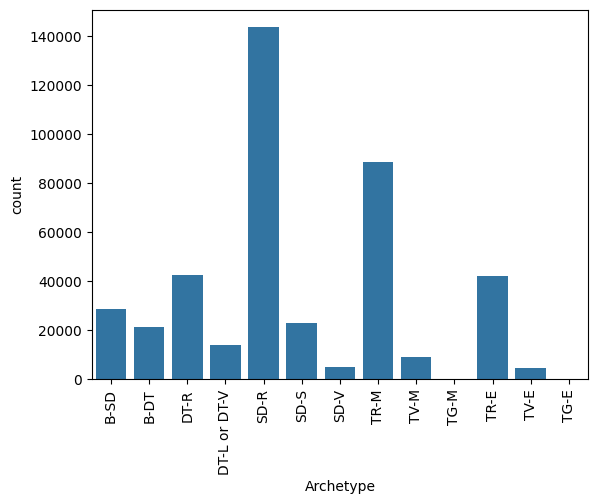

In [46]:
sns.barplot(dfarchetype)
plt.xticks(rotation=90)

# Check DT-L, DT-V, DT-R

In [47]:
dfd.tail(3)

,certificate_number,property_type,built_form,construction_age_band,floor_height,flat_storey_count,total_floor_area,Archetype
528904,9638-5080-7282-5468-4914,House,Detached,2003-2006,2.33,3.0,150.0,DT-R
528907,9718-9904-7200-3395-6944,House,Detached,1976-1982,2.30,2.0,89.0,DT-R
528913,9788-7053-7243-4266-0980,House,Detached,1996-2002,2.41,2.0,164.0,DT-L or DT-V


In [48]:
# We considered DT-L has 1~2 storey, and DT-V has more than 2 storey.

# Get to know storey count
flat_storey_count_list = dfd['flat_storey_count'].unique()
print("\nflat_storey_count with index numbers:")
for i, N_flat_storey_count in enumerate(flat_storey_count_list):
    count_FSC = len(dfd[dfd['flat_storey_count'] == N_flat_storey_count ])
    print(f"{i}: {N_flat_storey_count} ({count_FSC} records)")


flat_storey_count with index numbers:
0: 2.0 (49745 records)
1: 1.0 (2240 records)
2: 3.0 (2679 records)
3: nan (0 records)
4: 4.0 (109 records)
5: 7.0 (1 records)
6: 6.0 (3 records)
7: 5.0 (1 records)


# Archetypes

In [49]:
# concat both DataFrames into a single DataFrame

dfepc = pd.concat([dfb, dfd, dfs, dfe, dfm])

In [50]:
dfepc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 423351 entries, 12 to 528924
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   certificate_number     423351 non-null  object 
 1   property_type          423351 non-null  object 
 2   built_form             423318 non-null  object 
 3   construction_age_band  381924 non-null  object 
 4   floor_height           423351 non-null  float64
 5   flat_storey_count      417733 non-null  float64
 6   total_floor_area       423351 non-null  float64
 7   Archetype              423351 non-null  object 
dtypes: float64(3), object(5)
memory usage: 29.1+ MB


In [51]:
dfepc.head(3)

,certificate_number,property_type,built_form,construction_age_band,floor_height,flat_storey_count,total_floor_area,Archetype
12,0370-2699-6650-2125-1071,Bungalow,End-Terrace,1976-1982,2.38,1.0,40.0,B-SD
68,0536-1929-9500-0326-7206,Bungalow,Mid-Terrace,1967-1975,2.28,1.0,57.0,B-SD
103,0646-2848-7212-9823-5665,Bungalow,Detached,1950-1966,2.35,1.0,117.0,B-DT


In [52]:
# Get to know data
archetype_type_list = dfepc['Archetype'].unique()
print("\narchetype_type with index numbers:")
for i, N_archetype in enumerate(archetype_type_list):
    count_AR = len(dfepc[dfepc['Archetype'] == N_archetype ])
    print(f"{i}: {N_archetype} ({count_AR} records)")


archetype_type with index numbers:
0: B-SD (28810 records)
1: B-DT (21349 records)
2: DT-R (42502 records)
3: DT-L or DT-V (13886 records)
4: SD-R (143479 records)
5: SD-S (23119 records)
6: SD-V (4926 records)
7: TR-E (42253 records)
8: TV-E (4819 records)
9: TG-E (308 records)
10: TR-M (88455 records)
11: TV-M (9060 records)
12: TG-M (385 records)


# Postprocessed data 

In [53]:
# import Excel

Result = pd.read_excel('SY_Archetypes_Quantification_Results.xlsx', sheet_name='stocksize')

In [54]:
df_result= pd.DataFrame(Result)

In [55]:
df_result.head(2)

,Archetype,Verisk,EPC
0,*DT-V,35529,8339.500000
1,DT-L,30448,3697.666667


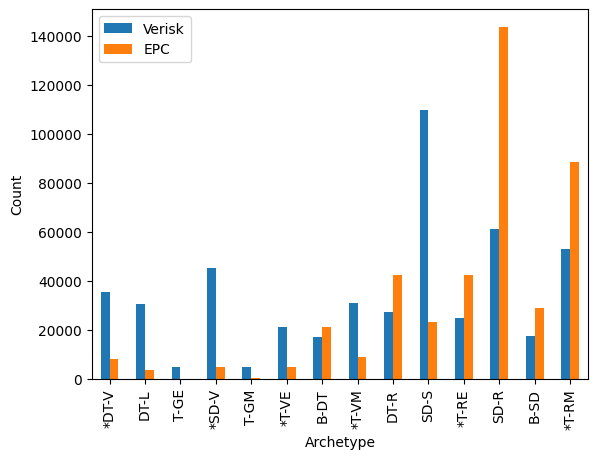

In [56]:
# Plotting side-by-side
df_result.plot(x='Archetype', y=['Verisk', 'EPC'], kind='bar')
plt.ylabel("Count")
plt.show()